In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [25]:
def wealth_hist_and_tail_fit(wealth, w_min=None):
    """
    From integer wealth array, compute N(w) = number of people with wealth w,
    and fit the tail N(w) ~ C * w^{-alpha} for w >= w_min.
    Returns (w_vals, counts, alpha, C, w_min).
    """
    wealth = np.asarray(wealth, dtype=int)
    #wealth = wealth[wealth > 0]
    # Histogram over integer wealth: index = wealth, value = count
    counts_all = np.bincount(wealth)      
    w_vals = np.arange(counts_all.size)[1:]   # drop wealth=0
    counts = counts_all[1:]

    # Choose a tail threshold if not provided (default: top 5% by wealth)
    if w_min is None:
        w_min = max(2, int(np.percentile(wealth, 95)))

    # Tail selection + filter zeros
    tail_mask = (w_vals >= w_min) & (counts > 0)
    x = np.log(w_vals[tail_mask])
    y = np.log(counts[tail_mask])

    if len(x) < 2:
        raise ValueError("Not enough nonzero tail bins to fit!")

    # Linear fit in log–log space: log N(w) = log C + (-alpha) * log w
    slope, intercept = np.polyfit(x, y, 1)
    alpha = -slope
    C = np.exp(intercept)

    # Plot: histogram counts and fitted tail
    plt.figure()
    plt.loglog(w_vals, counts, 'o', ms=3, label='count N(w)')
    plt.loglog(w_vals[tail_mask], C * w_vals[tail_mask]**(-alpha),
               '-', label=f'fit: α ≈ {alpha:.2f}, w_min={w_min}')
    plt.xlabel('wealth w')
    plt.ylabel('count N(w)')
    plt.legend()
    plt.tight_layout()
    plt.show()

    return w_vals, counts, alpha, C, w_min

In [26]:
i,j = np.random.randint(100, size=(2))
print(i,j)

50 77


In [27]:
def simulation(l, n):
    box = np.ones(l, dtype=np.int64)
    for _ in range(n):
        i,j = np.random.randint(l, size=2)
        while box[i] + box[j] == 0:
            i,j = np.random.randint(l, size=2)
        box[j] = box[i] + box[j] - 1
        box[i] =  np.random.choice([0,1,2])
    return np.sort(box)[::-1]


In [32]:
boxes = simulation(10000,100000)

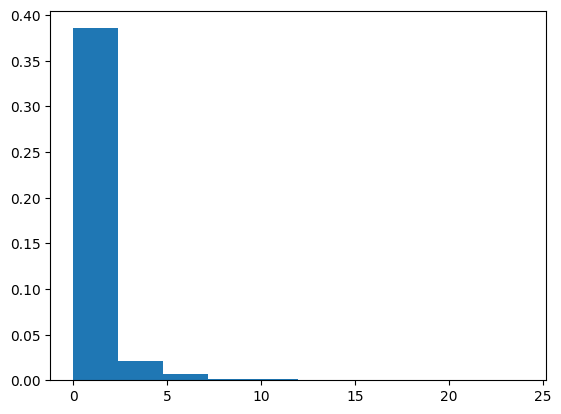

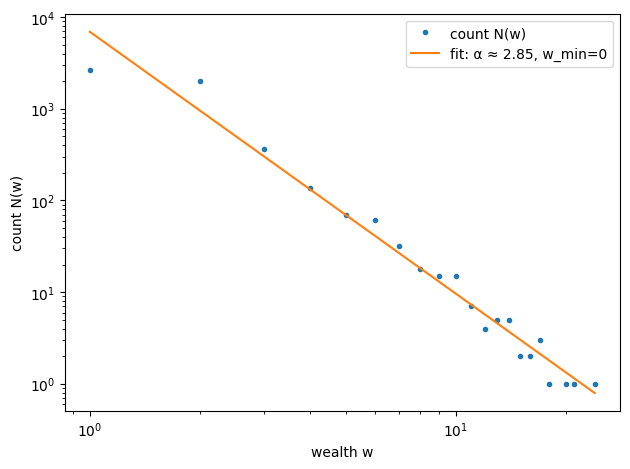

In [34]:
plt.hist(boxes, density=True)
_ = wealth_hist_and_tail_fit(boxes, w_min=0) # set w_min yourself, or leave None
